# 📉 Customer Churn Analysis — Exploratory Data Analysis

> **Goal:** Understand who is churning, why, and where the biggest business risks are.

**Author:** Your Name  
**Dataset:** Telco Customer Churn (Kaggle)  
**Last Updated:** 2026-03

---

### 📋 Table of Contents
1. [Setup & Load Data](#1-setup)
2. [Data Quality Check](#2-quality)
3. [Target Variable Analysis](#3-target)
4. [Churn by Contract Type](#4-contract)
5. [Churn by Tenure](#5-tenure)
6. [Churn by Services](#6-services)
7. [Churn by Payment Method](#7-payment)
8. [Revenue at Risk](#8-revenue)
9. [Correlation Heatmap](#9-correlation)
10. [Key Findings & Business Recommendations](#10-findings)

## 1. Setup & Load Data <a id='1-setup'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import sys
sys.path.append('..')

from src.data_cleaning import clean_pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# Run the cleaning pipeline (or load pre-cleaned if already done)
try:
    df = pd.read_csv('../data/cleaned/telco_churn_cleaned.csv')
    print(f'✅ Loaded cleaned data: {df.shape}')
except FileNotFoundError:
    df = clean_pipeline(
        raw_path='../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv',
        save_path='../data/cleaned/telco_churn_cleaned.csv'
    )

df.head()

✅ Loaded cleaned data: (7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_spend,num_services
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12 months,29.85,2
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,24-48 months,55.57,4
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12 months,54.08,4
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-48 months,40.91,4
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12 months,75.83,2


## 2. Data Quality Check <a id='2-quality'></a>

In [3]:
print('Shape:', df.shape)
print('\nColumn Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nDuplicates:', df.duplicated().sum())
df.describe()

Shape: (7043, 23)

Column Types:
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                  int64
tenure_group          object
avg_monthly_spend    float64
num_services           int64
dtype: object

Missing Values:
Series([], dtype: int64)

Duplicates: 22


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,avg_monthly_spend,num_services
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370,64.762889,4.146244
std,0.368612,24.559481,30.090047,2266.794470,0.441561,30.189824,2.312720
min,0.000000,0.000000,18.250000,0.000000,0.000000,13.780000,1.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000,35.935000,2.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000,70.340000,4.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000,90.170000,6.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,121.400000,9.000000


## 3. Target Variable — Churn Distribution <a id='3-target'></a>

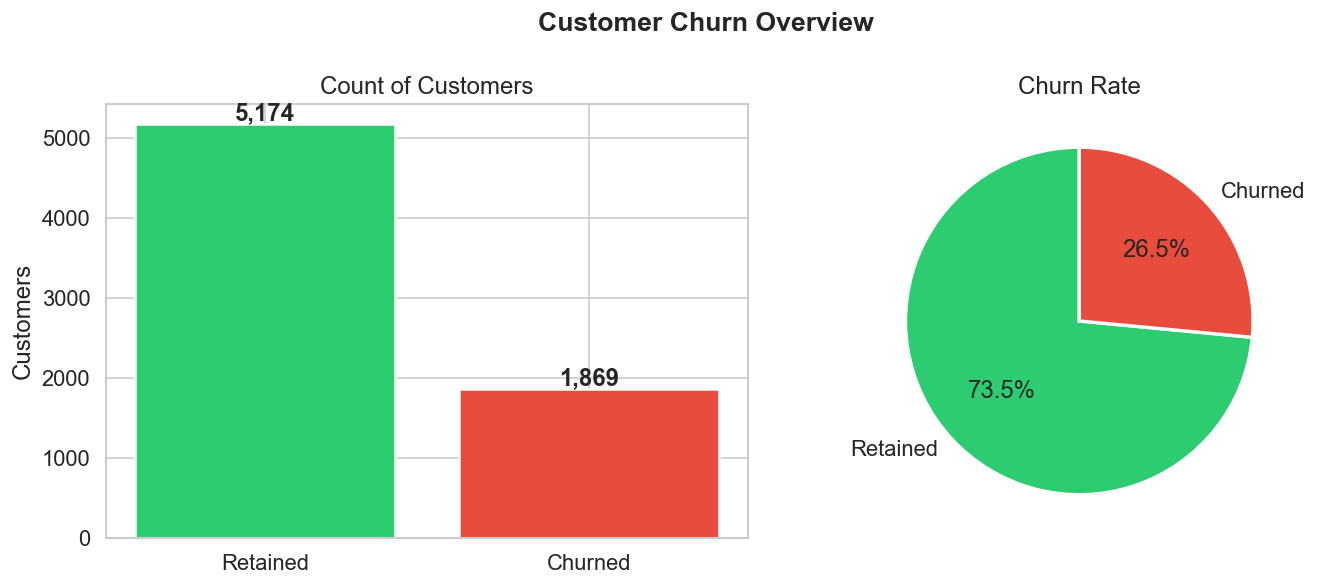


📌 Overall churn rate: 26.5%
   1,869 out of 7,043 customers churned


In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold')

# Bar chart
axes[0].bar(['Retained', 'Churned'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Count of Customers')
axes[0].set_ylabel('Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_pct.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.savefig('../docs/01_churn_overview.png', bbox_inches='tight')
plt.show()

print(f'\n📌 Overall churn rate: {churn_pct[1]}%')
print(f'   {churn_counts[1]:,} out of {len(df):,} customers churned')

## 4. Churn by Contract Type <a id='4-contract'></a>

In [5]:
contract_churn = df.groupby('Contract')['Churn'].mean().mul(100).round(1).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']
contract_churn = contract_churn.sort_values('Churn Rate (%)', ascending=False)

fig = px.bar(contract_churn, x='Contract', y='Churn Rate (%)',
             color='Churn Rate (%)', color_continuous_scale='RdYlGn_r',
             title='Churn Rate by Contract Type',
             text='Churn Rate (%)')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(showlegend=False, plot_bgcolor='white')
fig.show()

print(contract_churn.to_string(index=False))
print('\n📌 Insight: Month-to-month customers churn at the highest rate.')

      Contract  Churn Rate (%)
Month-to-month            42.7
      One year            11.3
      Two year             2.8

📌 Insight: Month-to-month customers churn at the highest rate.


## 5. Churn by Tenure <a id='5-tenure'></a>

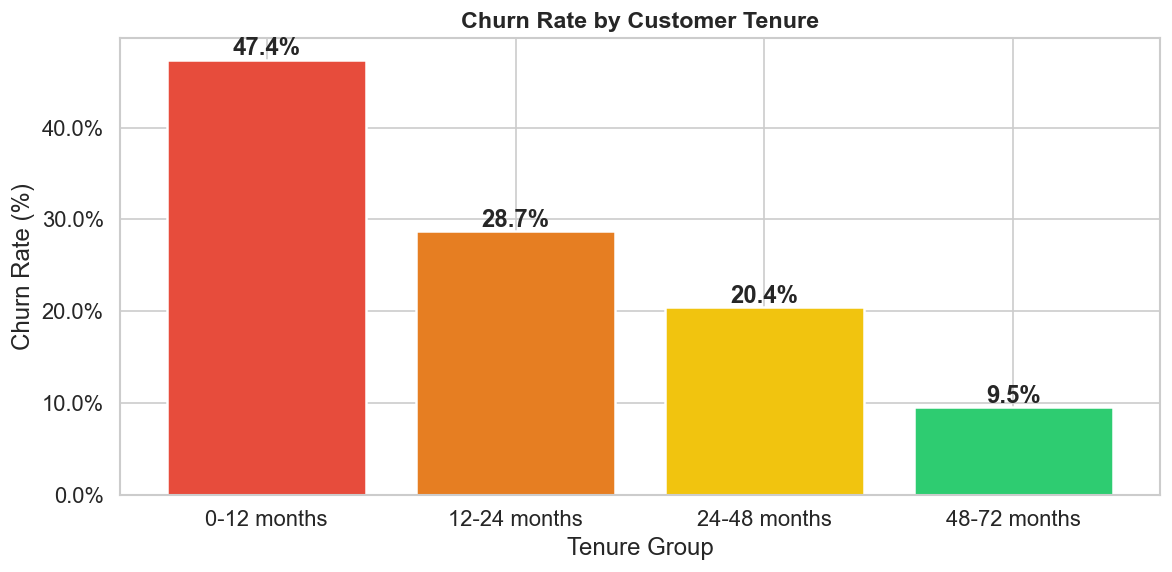


📌 Insight: Newest customers (0–12 months) are at highest risk.


In [6]:
tenure_churn = df.groupby('tenure_group')['Churn'].mean().mul(100).round(1).reset_index()
tenure_churn.columns = ['Tenure Group', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(tenure_churn['Tenure Group'], tenure_churn['Churn Rate (%)'],
              color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'],
              edgecolor='white', linewidth=1.5)
ax.set_title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(bars, tenure_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/02_churn_by_tenure.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Newest customers (0–12 months) are at highest risk.')

## 6. Churn by Internet Service & Tech Support <a id='6-services'></a>

In [7]:
service_churn = df.groupby(['InternetService', 'TechSupport'])['Churn'].mean().mul(100).round(1).reset_index()
service_churn.columns = ['Internet Service', 'Tech Support', 'Churn Rate (%)']

fig = px.bar(service_churn, x='Internet Service', y='Churn Rate (%)',
             color='Tech Support', barmode='group',
             title='Churn Rate by Internet Service & Tech Support',
             color_discrete_map={'Yes': '#2ecc71', 'No': '#e74c3c'},
             text='Churn Rate (%)')
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(plot_bgcolor='white')
fig.show()
print('\n📌 Insight: Fiber optic customers without tech support churn the most.')


📌 Insight: Fiber optic customers without tech support churn the most.


## 7. Churn by Payment Method <a id='7-payment'></a>

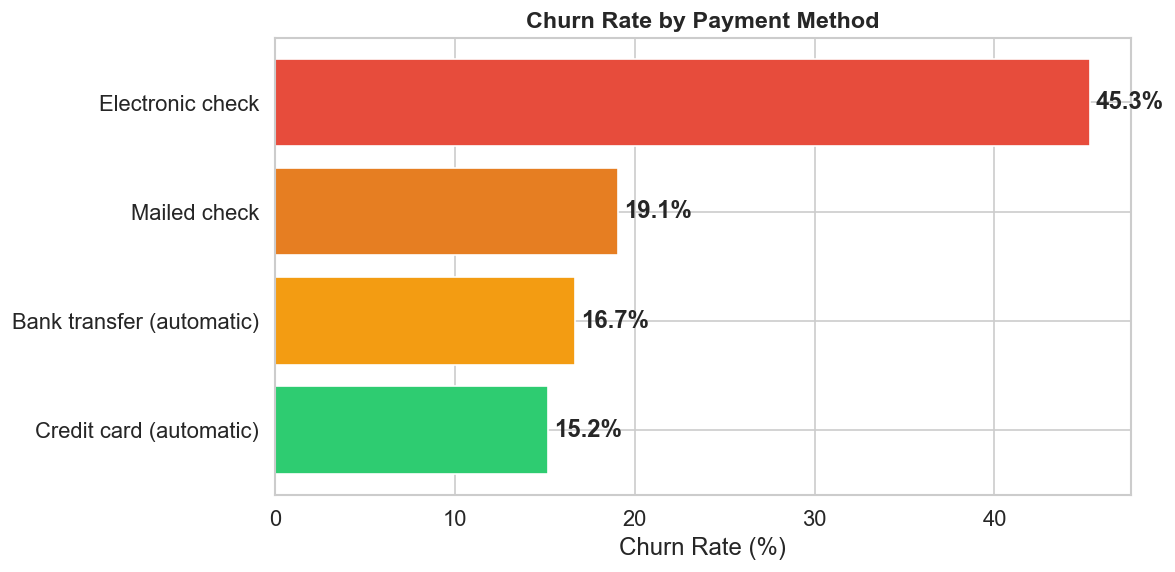


📌 Insight: Electronic check users churn at nearly 2x the rate of credit card users.


In [8]:
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().mul(100).round(1).reset_index()
payment_churn.columns = ['Payment Method', 'Churn Rate (%)']
payment_churn = payment_churn.sort_values('Churn Rate (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(payment_churn['Payment Method'], payment_churn['Churn Rate (%)'],
        color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
for i, v in enumerate(payment_churn['Churn Rate (%)']):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/03_churn_by_payment.png', bbox_inches='tight')
plt.show()
print('\n📌 Insight: Electronic check users churn at nearly 2x the rate of credit card users.')

## 8. Revenue at Risk <a id='8-revenue'></a>

💰 Revenue Impact Summary
Monthly revenue at risk (churned):  $139,131
Avg monthly charge — Churned:        $74.44
Avg monthly charge — Retained:       $61.27
Churn premium (churned pay more):    $13.18/mo


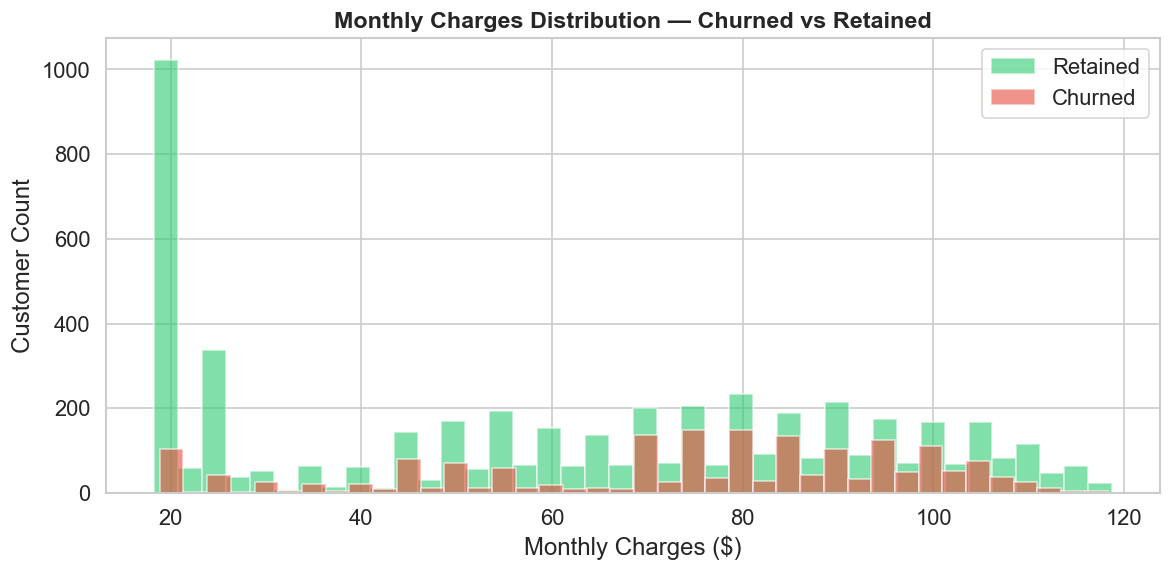

In [9]:
churned_df = df[df['Churn'] == 1]
retained_df = df[df['Churn'] == 0]

monthly_revenue_at_risk = churned_df['MonthlyCharges'].sum()
avg_charges_churned = churned_df['MonthlyCharges'].mean()
avg_charges_retained = retained_df['MonthlyCharges'].mean()

print('💰 Revenue Impact Summary')
print('=' * 40)
print(f'Monthly revenue at risk (churned):  ${monthly_revenue_at_risk:,.0f}')
print(f'Avg monthly charge — Churned:        ${avg_charges_churned:.2f}')
print(f'Avg monthly charge — Retained:       ${avg_charges_retained:.2f}')
print(f'Churn premium (churned pay more):    ${avg_charges_churned - avg_charges_retained:.2f}/mo')

# Monthly charges distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(retained_df['MonthlyCharges'], bins=40, alpha=0.6, label='Retained', color='#2ecc71')
ax.hist(churned_df['MonthlyCharges'],  bins=40, alpha=0.6, label='Churned',  color='#e74c3c')
ax.set_title('Monthly Charges Distribution — Churned vs Retained', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Customer Count')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/04_revenue_at_risk.png', bbox_inches='tight')
plt.show()

## 9. Correlation Heatmap <a id='9-correlation'></a>

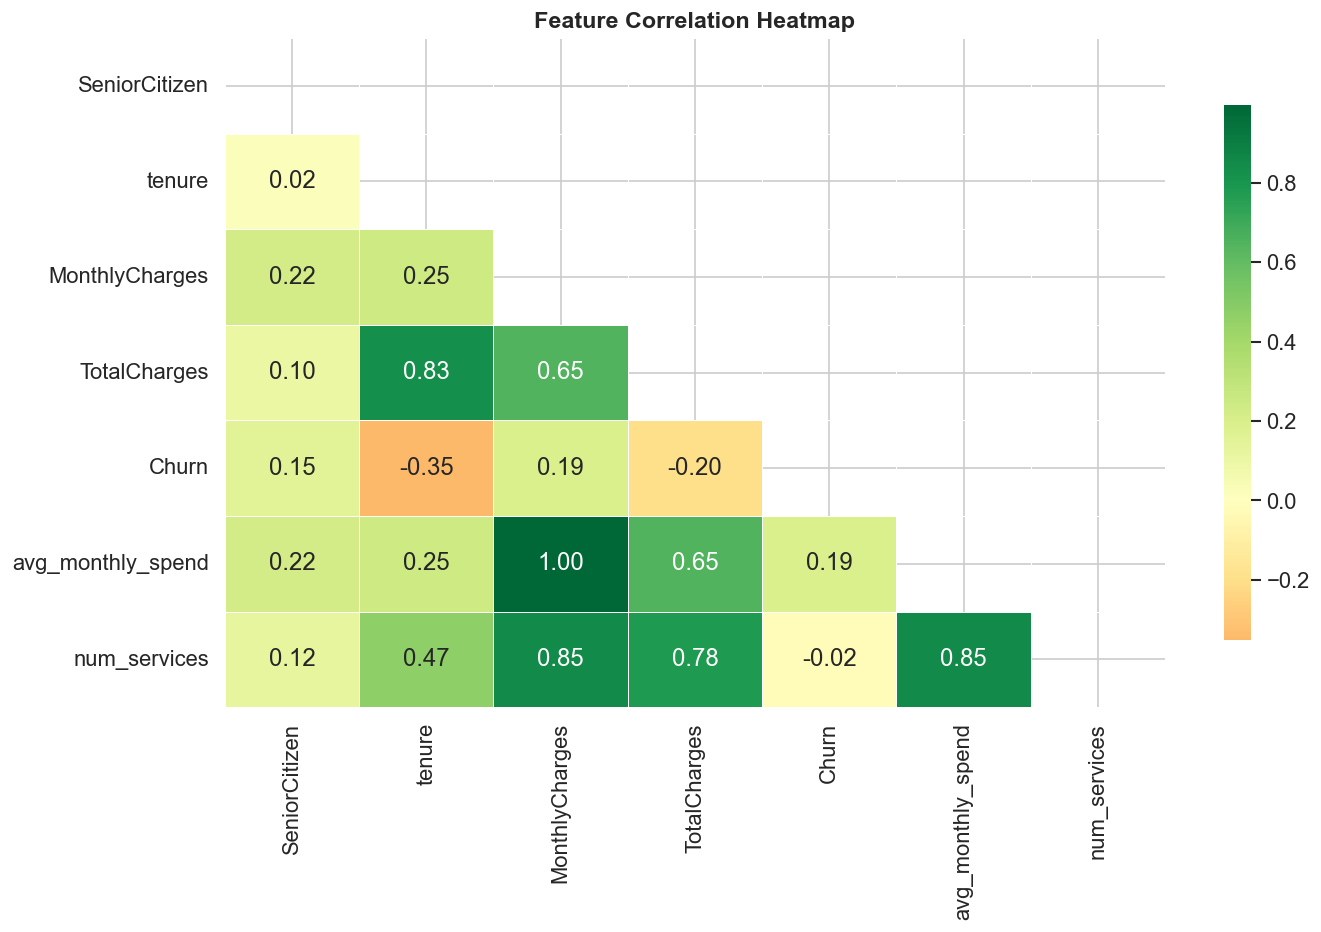

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 10. Key Findings & Business Recommendations <a id='10-findings'></a>

---

### 📌 Key Findings

| # | Finding | Churn Rate |
|---|---|---|
| 1 | Month-to-month contract customers | ~42% |
| 2 | Customers in first 12 months | ~50%+ |
| 3 | Fiber optic users without tech support | ~41% |
| 4 | Electronic check payment users | ~45% |

---

### 💡 Business Recommendations

1. **Onboarding Program (0–12 month segment)**  
   Launch a structured onboarding flow targeting new customers. Proactive check-ins at months 1, 3, 6 can significantly reduce early churn.

2. **Annual Contract Incentives**  
   Offer first-month discounts or loyalty credits to move month-to-month customers to annual plans.

3. **Tech Support Upsell for Fiber Customers**  
   Fiber customers without tech support are the highest churn risk. A targeted upsell campaign could reduce churn while increasing ARPU.

4. **Payment Method Nudges**  
   Incentivise customers to switch from electronic checks to auto-pay via credit card (e.g. 5% bill discount).

---

### 🔭 Next Steps
- Build an XGBoost churn prediction model (Phase 2)
- Add SHAP feature importance for explainability
- Deploy predictions via Streamlit dashboard